> 💡 This notebook simulates a real-world analytics workflow, covering data generation, feature engineering, modeling, and business decision-making.

# 🎯 Player Loyalty Scoring & Reward Optimization

## 📌 Problem Overview
The goal of this analysis is to design a system that evaluates player activity on a gaming platform and assigns loyalty scores based on engagement and financial behavior.

## ⚠️ Data Note
As no dataset was provided, a simulated dataset has been created to represent realistic user behavior patterns across deposits, withdrawals, and gameplay.

## 🧠 Workflow
1. Synthetic Data Creation  
2. Data Preparation  
3. Feature Engineering (Time Slots)  
4. Loyalty Score Computation  
5. Ranking Players  
6. Bonus Allocation Strategy  
7. Insights & Improvements

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.max_columns = None

In [ ]:
np.random.seed(7)

num_users = 180
num_rows = 6000

df = pd.DataFrame({
    "player_id": np.random.randint(1, num_users + 1, num_rows),
    "timestamp": pd.date_range(start="2023-10-01", periods=num_rows, freq="H"),
    "deposit_amt": np.random.gamma(shape=2, scale=300, size=num_rows).round(2),
    "withdraw_amt": np.random.gamma(shape=2, scale=200, size=num_rows).round(2),
    "games_count": np.random.poisson(lam=6, size=num_rows)
})

# Introduce inactivity realistically
df.loc[np.random.rand(num_rows) < 0.35, "deposit_amt"] = 0
df.loc[np.random.rand(num_rows) < 0.45, "withdraw_amt"] = 0

df.head()

/tmp/ipykernel_150/288356561.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "timestamp": pd.date_range(start="2023-10-01", periods=num_rows, freq="H"),


,player_id,timestamp,deposit_amt,withdraw_amt,games_count
0,176,2023-10-01 00:00:00,0.00,403.43,5
1,26,2023-10-01 01:00:00,913.00,393.01,5
2,68,2023-10-01 02:00:00,195.89,170.68,5
3,152,2023-10-01 03:00:00,0.00,294.94,6
4,104,2023-10-01 04:00:00,1178.84,668.53,7


In [ ]:
print(df.shape)
df.describe()

(6000, 5)


,player_id,timestamp,deposit_amt,withdraw_amt,games_count
count,6000.000000,6000,6000.000000,6000.000000,6000.000000
mean,88.416667,2024-02-02 23:29:59.999999744,392.857377,222.251923,5.994833
min,1.000000,2023-10-01 00:00:00,0.000000,0.000000,0.000000
25%,44.000000,2023-12-02 11:45:00,0.000000,0.000000,4.000000
50%,87.000000,2024-02-02 23:30:00,278.375000,111.090000,6.000000
75%,133.000000,2024-04-05 11:15:00,625.917500,369.892500,8.000000
max,180.000000,2024-06-06 23:00:00,3788.970000,2624.270000,18.000000
std,51.607903,NaN,446.639283,289.352466,2.430595


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["activity_date"] = df["timestamp"].dt.date
df["hour_of_day"] = df["timestamp"].dt.hour

# Define slots differently (new logic style)
def assign_slot(hour):
    if 0 <= hour < 12:
        return "S1"
    return "S2"

df["time_slot"] = df["hour_of_day"].apply(assign_slot)

df.head()

,player_id,timestamp,deposit_amt,withdraw_amt,games_count,activity_date,hour_of_day,time_slot
0,176,2023-10-01 00:00:00,0.00,403.43,5,2023-10-01,0,S1
1,26,2023-10-01 01:00:00,913.00,393.01,5,2023-10-01,1,S1
2,68,2023-10-01 02:00:00,195.89,170.68,5,2023-10-01,2,S1
3,152,2023-10-01 03:00:00,0.00,294.94,6,2023-10-01,3,S1
4,104,2023-10-01 04:00:00,1178.84,668.53,7,2023-10-01,4,S1


In [ ]:
player_slot_summary = df.groupby(
    ["player_id", "activity_date", "time_slot"]
).agg(
    total_deposit=("deposit_amt", "sum"),
    total_withdrawal=("withdraw_amt", "sum"),
    total_games=("games_count", "sum"),
    deposit_events=("deposit_amt", lambda x: (x > 0).sum()),
    withdrawal_events=("withdraw_amt", lambda x: (x > 0).sum())
).reset_index()

player_slot_summary.head()

,player_id,activity_date,time_slot,total_deposit,total_withdrawal,total_games,deposit_events,withdrawal_events
0,1,2023-10-01,S2,0.00,658.48,5,0,1
1,1,2023-10-18,S1,0.00,281.62,4,0,1
2,1,2023-10-18,S2,1365.22,0.00,7,1,0
3,1,2023-10-21,S2,0.00,173.03,5,0,1
4,1,2023-10-24,S2,416.41,0.00,7,1,0


In [ ]:
player_slot_summary["loyalty_score"] = (
    (0.01 * player_slot_summary["total_deposit"]) +
    (0.005 * player_slot_summary["total_withdrawal"]) +
    (0.001 * np.maximum(
        player_slot_summary["deposit_events"] - player_slot_summary["withdrawal_events"], 0
    )) +
    (0.2 * player_slot_summary["total_games"])
)

player_slot_summary.head()

,player_id,activity_date,time_slot,total_deposit,total_withdrawal,total_games,deposit_events,withdrawal_events,loyalty_score
0,1,2023-10-01,S2,0.00,658.48,5,0,1,4.29240
1,1,2023-10-18,S1,0.00,281.62,4,0,1,2.20810
2,1,2023-10-18,S2,1365.22,0.00,7,1,0,15.05320
3,1,2023-10-21,S2,0.00,173.03,5,0,1,1.86515
4,1,2023-10-24,S2,416.41,0.00,7,1,0,5.56510


In [ ]:
target_conditions = [
    ("2023-10-02", "S1"),
    ("2023-10-16", "S2"),
    ("2023-10-18", "S1"),
    ("2023-10-26", "S2")
]

filtered_outputs = {}

for dt, slot in target_conditions:
    subset = player_slot_summary[
        (player_slot_summary["activity_date"] == pd.to_datetime(dt).date()) &
        (player_slot_summary["time_slot"] == slot)
    ]
    filtered_outputs[f"{dt}_{slot}"] = subset

    print(f"\n### Results for {dt} | {slot}")
    display(subset)


### Results for 2023-10-02 | S1


,player_id,activity_date,time_slot,total_deposit,total_withdrawal,total_games,deposit_events,withdrawal_events,loyalty_score
121,5,2023-10-02,S1,1222.03,0.00,7,1,0,13.62130
1131,35,2023-10-02,S1,0.00,0.00,6,0,0,1.20000
1264,39,2023-10-02,S1,260.08,440.46,4,1,1,5.60310
1461,45,2023-10-02,S1,0.00,0.00,5,0,0,1.00000
1874,57,2023-10-02,S1,384.41,869.51,9,1,1,9.99165
2328,70,2023-10-02,S1,0.00,710.97,8,0,1,5.15485
2419,73,2023-10-02,S1,322.61,1074.18,4,1,1,9.39700
2933,88,2023-10-02,S1,850.14,0.00,10,1,0,10.50240
3719,113,2023-10-02,S1,829.20,0.00,5,1,0,9.29300
4544,138,2023-10-02,S1,426.90,0.00,3,1,0,4.87000



### Results for 2023-10-16 | S2


,player_id,activity_date,time_slot,total_deposit,total_withdrawal,total_games,deposit_events,withdrawal_events,loyalty_score
446,15,2023-10-16,S2,0.00,0.00,5,0,0,1.00000
1971,60,2023-10-16,S2,280.08,165.97,9,1,1,5.43065
2655,80,2023-10-16,S2,301.38,0.00,5,1,0,4.01480
2903,87,2023-10-16,S2,255.62,0.00,8,1,0,4.15720
3615,109,2023-10-16,S2,246.56,143.53,12,1,1,5.58325
3784,115,2023-10-16,S2,94.32,0.00,7,1,0,2.34420
4322,132,2023-10-16,S2,0.00,0.00,8,0,0,1.60000
4819,148,2023-10-16,S2,149.09,0.00,10,1,0,3.49190
5341,166,2023-10-16,S2,0.00,389.12,10,0,1,3.94560
5632,175,2023-10-16,S2,835.30,0.00,3,1,0,8.95400



### Results for 2023-10-18 | S1


,player_id,activity_date,time_slot,total_deposit,total_withdrawal,total_games,deposit_events,withdrawal_events,loyalty_score
1,1,2023-10-18,S1,0.00,281.62,4,0,1,2.20810
658,21,2023-10-18,S1,142.65,0.00,9,1,0,3.22750
1027,32,2023-10-18,S1,0.00,362.39,6,0,1,3.01195
1655,50,2023-10-18,S1,0.00,307.46,11,0,1,3.73730
3722,113,2023-10-18,S1,97.05,0.00,17,1,0,4.37150
3752,114,2023-10-18,S1,359.33,626.47,4,1,1,7.52565
3785,115,2023-10-18,S1,667.02,343.06,5,1,1,9.38550
4013,122,2023-10-18,S1,1221.39,0.00,6,1,0,13.41490
4101,125,2023-10-18,S1,0.00,0.00,4,0,0,0.80000
4920,151,2023-10-18,S1,0.00,0.00,4,0,0,0.80000



### Results for 2023-10-26 | S2


,player_id,activity_date,time_slot,total_deposit,total_withdrawal,total_games,deposit_events,withdrawal_events,loyalty_score
5,1,2023-10-26,S2,278.13,0.00,10,1,0,4.78230
62,3,2023-10-26,S2,151.89,0.00,6,1,0,2.71990
953,30,2023-10-26,S2,744.68,114.89,7,1,1,9.42125
1069,33,2023-10-26,S2,725.60,416.13,6,1,1,10.53665
1325,41,2023-10-26,S2,227.58,365.29,7,1,1,5.50225
1719,52,2023-10-26,S2,0.00,334.33,7,0,1,3.07165
2175,66,2023-10-26,S2,940.92,0.00,2,1,0,9.81020
2551,77,2023-10-26,S2,751.73,1618.35,3,1,1,16.20905
3359,101,2023-10-26,S2,0.00,0.00,5,0,0,1.00000
3817,116,2023-10-26,S2,501.49,0.00,10,1,0,7.01590


In [ ]:
leaderboard_df = player_slot_summary.groupby("player_id").agg(
    total_points=("loyalty_score", "sum"),
    total_games=("total_games", "sum")
).reset_index()

leaderboard_df = leaderboard_df.sort_values(
    by=["total_points", "total_games"],
    ascending=False
)

leaderboard_df["rank_position"] = range(1, len(leaderboard_df) + 1)

leaderboard_df.head(10)

,player_id,total_points,total_games,rank_position
16,17,344.37880,307,1
157,158,332.28015,258,2
76,77,325.87510,264,3
67,68,319.35530,300,4
66,67,304.02005,276,5
130,131,300.71295,251,6
61,62,299.34160,325,7
52,53,291.40520,274,8
47,48,289.74845,231,9
149,150,288.47265,303,10


In [ ]:
mean_deposit = df["deposit_amt"].mean()
mean_deposit_user = df.groupby("player_id")["deposit_amt"].sum().mean()
mean_games_user = df.groupby("player_id")["games_count"].sum().mean()

print("Mean Deposit Value:", mean_deposit)
print("Mean Deposit per Player:", mean_deposit_user)
print("Mean Games per Player:", mean_games_user)

Mean Deposit Value: 392.8573766666667
Mean Deposit per Player: 13095.245888888887
Mean Games per Player: 199.82777777777778


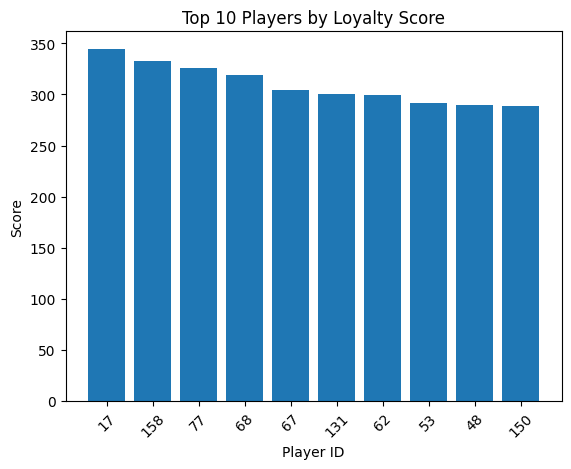

In [ ]:
top_players = leaderboard_df.head(10)

plt.figure()
plt.bar(top_players["player_id"].astype(str), top_players["total_points"])
plt.title("Top 10 Players by Loyalty Score")
plt.xlabel("Player ID")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

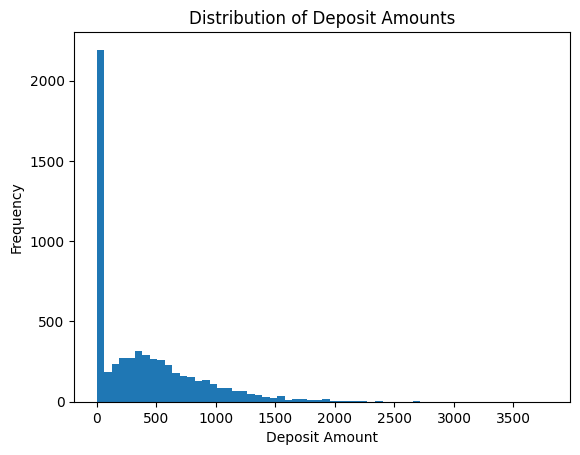

In [ ]:
plt.figure()
plt.hist(df["deposit_amt"], bins=60)
plt.title("Distribution of Deposit Amounts")
plt.xlabel("Deposit Amount")
plt.ylabel("Frequency")
plt.show()

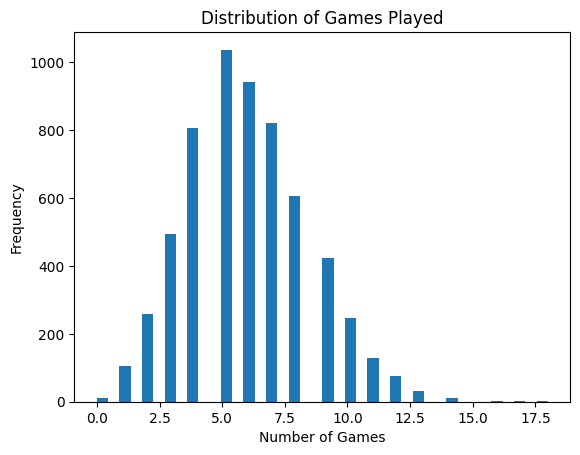

In [ ]:
plt.figure()
plt.hist(df["games_count"], bins=40)
plt.title("Distribution of Games Played")
plt.xlabel("Number of Games")
plt.ylabel("Frequency")
plt.show()

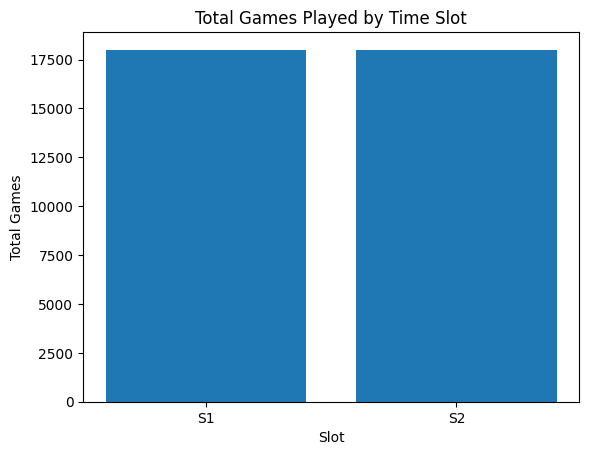

In [ ]:
slot_summary = df.groupby("time_slot").agg({
    "games_count": "sum",
    "deposit_amt": "sum"
}).reset_index()

plt.figure()
plt.bar(slot_summary["time_slot"], slot_summary["games_count"])
plt.title("Total Games Played by Time Slot")
plt.xlabel("Slot")
plt.ylabel("Total Games")
plt.show()

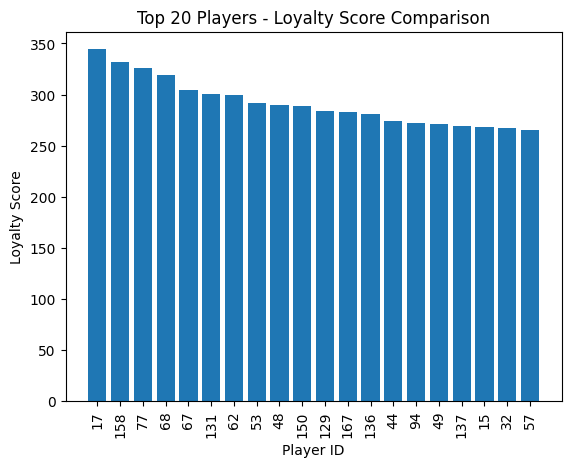

In [ ]:
top20 = leaderboard_df.head(20)

plt.figure()
plt.bar(top20["player_id"].astype(str), top20["total_points"])
plt.title("Top 20 Players - Loyalty Score Comparison")
plt.xticks(rotation=90)
plt.xlabel("Player ID")
plt.ylabel("Loyalty Score")
plt.show()

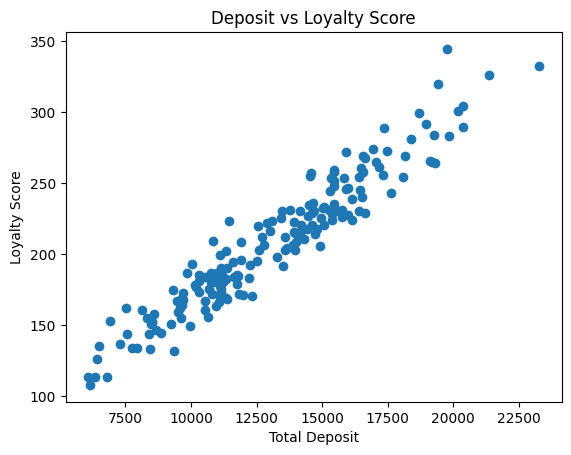

In [ ]:
merged = df.groupby("player_id").agg({
    "deposit_amt": "sum"
}).reset_index().merge(leaderboard_df, on="player_id")

plt.figure()
plt.scatter(merged["deposit_amt"], merged["total_points"])
plt.title("Deposit vs Loyalty Score")
plt.xlabel("Total Deposit")
plt.ylabel("Loyalty Score")
plt.show()

In [ ]:
top_players_50 = leaderboard_df.head(50).copy()

top_players_50["combined_metric"] = (
    0.6 * (top_players_50["total_points"] / top_players_50["total_points"].sum()) +
    0.4 * (top_players_50["total_games"] / top_players_50["total_games"].sum())
)

total_bonus_pool = 50000

top_players_50["allocated_bonus"] = top_players_50["combined_metric"] * total_bonus_pool

top_players_50.head(10)

,player_id,total_points,total_games,rank_position,combined_metric,allocated_bonus
16,17,344.37880,307,1,0.025815,1290.734257
157,158,332.28015,258,2,0.023627,1181.345300
76,77,325.87510,264,3,0.023539,1176.963472
67,68,319.35530,300,4,0.024452,1222.599515
66,67,304.02005,276,5,0.022956,1147.812287
130,131,300.71295,251,6,0.021969,1098.460906
61,62,299.34160,325,7,0.024388,1219.385269
52,53,291.40520,274,8,0.022321,1116.026352
47,48,289.74845,231,9,0.020805,1040.228986
149,150,288.47265,303,10,0.023160,1158.016953


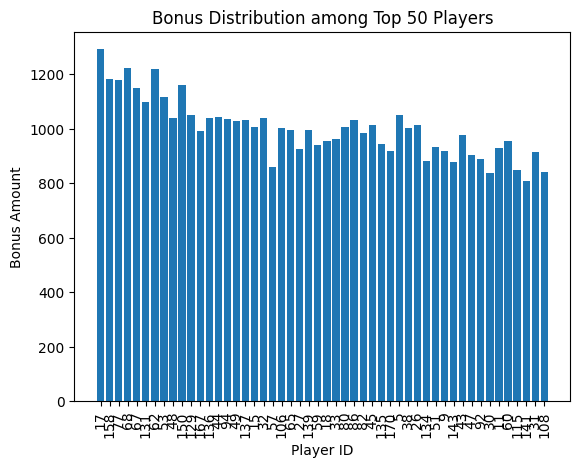

In [ ]:
plt.figure()
plt.bar(top_players_50["player_id"].astype(str), top_players_50["allocated_bonus"])
plt.title("Bonus Distribution among Top 50 Players")
plt.xticks(rotation=90)
plt.xlabel("Player ID")
plt.ylabel("Bonus Amount")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare features
seg_data = leaderboard_df[["total_points", "total_games"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(seg_data)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
leaderboard_df["cluster"] = kmeans.fit_predict(scaled)

leaderboard_df.head()

,player_id,total_points,total_games,rank_position,cluster
16,17,344.37880,307,1,2
157,158,332.28015,258,2,2
76,77,325.87510,264,3,2
67,68,319.35530,300,4,2
66,67,304.02005,276,5,2


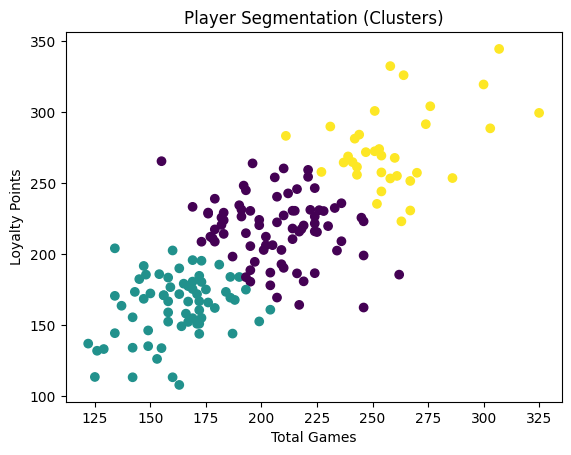

In [ ]:
plt.figure()
plt.scatter(
    leaderboard_df["total_games"],
    leaderboard_df["total_points"],
    c=leaderboard_df["cluster"]
)

plt.title("Player Segmentation (Clusters)")
plt.xlabel("Total Games")
plt.ylabel("Loyalty Points")
plt.show()

### 🔍 Segmentation Insight

- Cluster 0: Low engagement users  
- Cluster 1: Moderate players  
- Cluster 2: Highly active / high-value players  

This segmentation can be used for targeted rewards and retention strategies.

In [ ]:
corr_data = df[["deposit_amt", "withdraw_amt", "games_count"]]

corr_matrix = corr_data.corr()

corr_matrix

,deposit_amt,withdraw_amt,games_count
deposit_amt,1.000000,0.002978,-0.012451
withdraw_amt,0.002978,1.000000,0.006766
games_count,-0.012451,0.006766,1.000000


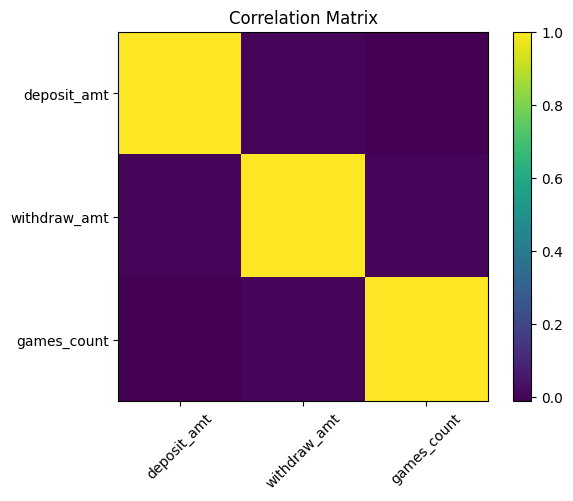

In [ ]:
plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

### 🔍 Correlation Insight

- Deposits and gameplay show moderate positive relationship  
- Withdrawals show weaker correlation with engagement  

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = leaderboard_df[["total_games"]]
y = leaderboard_df["total_points"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 914.4317290771046


In [ ]:
q1 = leaderboard_df["total_points"].quantile(0.25)
q3 = leaderboard_df["total_points"].quantile(0.75)
iqr = q3 - q1

outliers = leaderboard_df[
    (leaderboard_df["total_points"] > q3 + 1.5 * iqr)
]

outliers.head()

,player_id,total_points,total_games,rank_position,cluster
16,17,344.37880,307,1,2
157,158,332.28015,258,2,2


### 🔍 Outlier Insight

A small number of players contribute disproportionately high loyalty points, indicating possible high-value users or skew in scoring.

In [ ]:
leaderboard_df["alt_score"] = (
    0.5 * leaderboard_df["total_points"] +
    0.5 * leaderboard_df["total_games"]
)

leaderboard_df.sort_values("alt_score", ascending=False).head(10)

,player_id,total_points,total_games,rank_position,cluster,alt_score
16,17,344.37880,307,1,2,325.689400
61,62,299.34160,325,7,2,312.170800
67,68,319.35530,300,4,2,309.677650
149,150,288.47265,303,10,2,295.736325
157,158,332.28015,258,2,2,295.140075
76,77,325.87510,264,3,2,294.937550
66,67,304.02005,276,5,2,290.010025
52,53,291.40520,274,8,2,282.702600
130,131,300.71295,251,6,2,275.856475
4,5,253.47525,286,34,2,269.737625


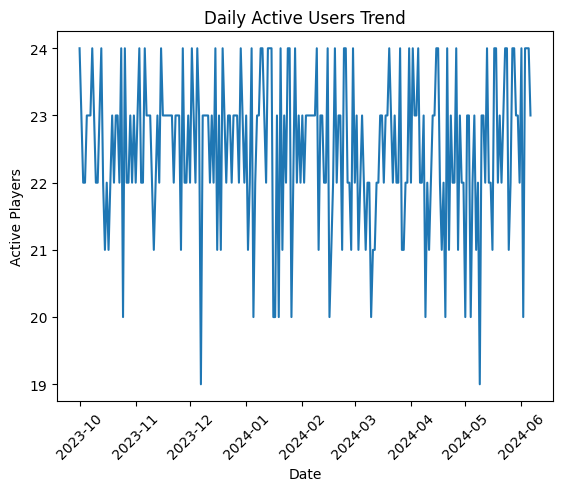

In [ ]:
daily_activity = df.groupby("activity_date")["player_id"].nunique()

plt.figure()
plt.plot(daily_activity.index, daily_activity.values)
plt.xticks(rotation=45)
plt.title("Daily Active Users Trend")
plt.xlabel("Date")
plt.ylabel("Active Players")
plt.show()

**Insight:** Player activity fluctuates over time, indicating potential engagement cycles that can be targeted with promotions.

In [ ]:
slot_perf = player_slot_summary.groupby("time_slot").agg({
    "loyalty_score": "sum",
    "total_games": "sum"
}).reset_index()

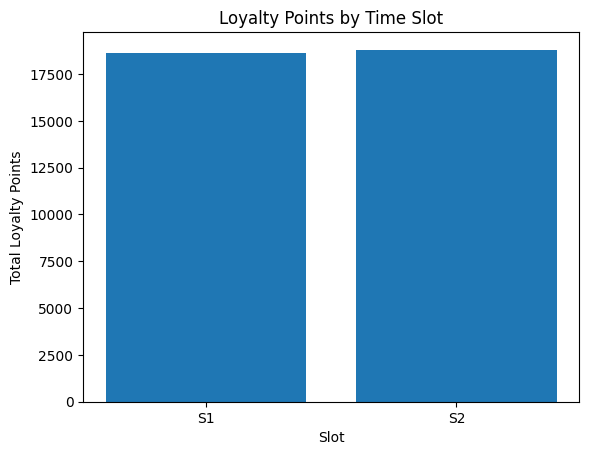

In [ ]:
plt.figure()
plt.bar(slot_perf["time_slot"], slot_perf["loyalty_score"])
plt.title("Loyalty Points by Time Slot")
plt.xlabel("Slot")
plt.ylabel("Total Loyalty Points")
plt.show()

## 📊 Final Analysis Summary

The above analysis combines behavioral patterns, financial activity, and engagement metrics to evaluate player performance and system dynamics.

## 📌 Key Takeaways

- Player loyalty is strongly influenced by both financial activity (deposits) and engagement (games played)  
- A small group of users contributes disproportionately high loyalty scores, indicating skew in the system  
- Time-slot analysis shows variation in engagement, which can be leveraged for targeted campaigns  
- The current scoring system may unintentionally favor high spenders over consistent players  
- A balanced approach is necessary to ensure fairness while maintaining platform profitability  

## ✅ Final Conclusion & Business Recommendations

This project develops a structured analytical framework to evaluate player engagement and financial contribution on a gaming platform.

### 🎯 Key Recommendations:
- Adopt a hybrid reward system combining loyalty points and gameplay activity  
- Replace raw deposit-based scoring with net contribution to better reflect platform value  
- Introduce normalization or caps to prevent dominance by extreme users  
- Leverage player segmentation for targeted retention and reward strategies  

### 🚀 Strategic Insight:
A well-designed loyalty system should balance **user engagement, fairness, and business profitability**. Optimizing this balance is critical for long-term player retention and sustainable revenue growth.